In [1]:
# Experiment 5: Random Forest Classifier

# Step 1: Import required libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 2: Load the dataset
iris = load_iris()

X = iris.data
y = iris.target

# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 4: Create a Random Forest classifier model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Step 5: Train the model using training data
model.fit(X_train, y_train)

# Step 6: Predict testing data
y_pred = model.predict(X_test)

# Step 7: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Classification")
print("----------------------------")

print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

# Step 8: Display actual and predicted values
print("\nActual vs Predicted Values:")
print("--------------------------------")

for actual, predicted in zip(y_test, y_pred):
    print(
        f"Actual: {iris.target_names[actual]:12} "
        f"Predicted: {iris.target_names[predicted]}"
    )

Random Forest Classification
----------------------------

Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Actual vs Predicted Values:
--------------------------------
Actual: setosa       Predicted: setosa
Actual: virginica    Predicted: virginica
Actual: versicolor   Predicted: versicolor
Actual: versicolor   Predicted: versicolor
Actual: setosa       Predicted: setosa
Actual: versicolor   Predicted: versicolor
Actual: setosa       Predicted: setosa
Actual: setosa       Predicted: setosa
Actual: virginica    Predicted: virginica
Actual: versicolor   Predicted: versicolor
Actual: virginica    Predicted: virginica
Actual

Customer Dataset:
    CustomerID  Annual_Income  Spending_Score
0            1             15              39
1            2             16              42
2            3             17              45
3            4             18              41
4            5             20              40
5            6             35              75
6            7             38              78
7            8             40              72
8            9             42              80
9           10             45              76
10          11             60              50
11          12             62              55
12          13             65              48
13          14             68              52
14          15             70              58
15          16             85              20
16          17             88              25
17          18             90              18
18          19             95              22
19          20            100              28


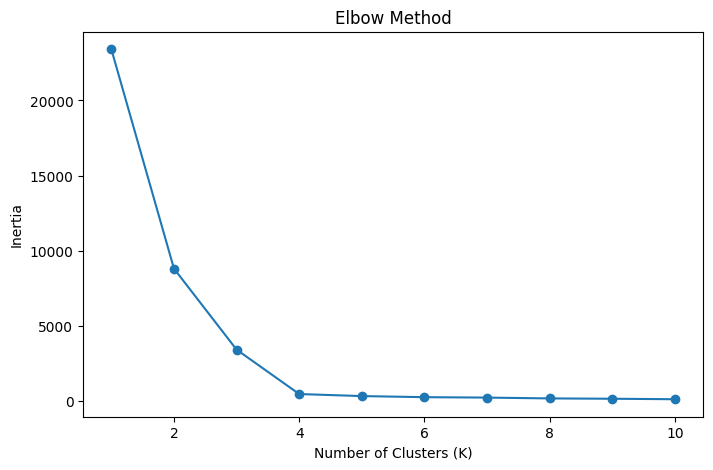


Customer Cluster Assignments:
    CustomerID  Annual_Income  Spending_Score  Cluster
0            1             15              39        2
1            2             16              42        2
2            3             17              45        2
3            4             18              41        2
4            5             20              40        2
5            6             35              75        0
6            7             38              78        0
7            8             40              72        0
8            9             42              80        0
9           10             45              76        0
10          11             60              50        0
11          12             62              55        0
12          13             65              48        0
13          14             68              52        0
14          15             70              58        0
15          16             85              20        1
16          17             88     

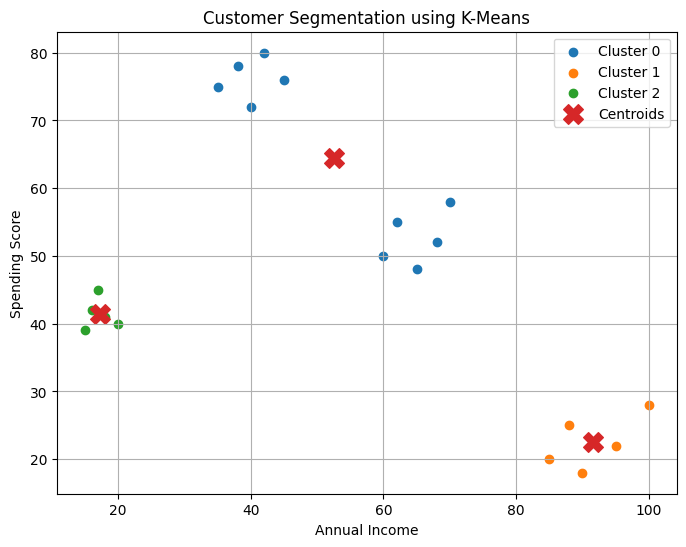

In [2]:
# Experiment 6: Customer Segmentation Using K-Means Clustering

# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 2: Create/Load the customer dataset

data = {
    'CustomerID': range(1, 21),
    'Annual_Income': [
        15, 16, 17, 18, 20,
        35, 38, 40, 42, 45,
        60, 62, 65, 68, 70,
        85, 88, 90, 95, 100
    ],
    'Spending_Score': [
        39, 42, 45, 41, 40,
        75, 78, 72, 80, 76,
        50, 55, 48, 52, 58,
        20, 25, 18, 22, 28
    ]
}

df = pd.DataFrame(data)

print("Customer Dataset:")
print(df)

# Step 3: Select features for clustering

X = df[['Annual_Income', 'Spending_Score']]

# Step 4: Use the Elbow Method to find optimal number of clusters

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Step 5: Apply K-Means clustering with chosen K value

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Step 6: Fit the model and predict cluster labels

df['Cluster'] = kmeans.fit_predict(X)

print("\nCustomer Cluster Assignments:")
print(df)

# Step 7: Visualize clusters and centroids

plt.figure(figsize=(8, 6))

for cluster in range(3):
    cluster_data = df[df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['Annual_Income'],
        cluster_data['Spending_Score'],
        label=f'Cluster {cluster}'
    )

# Plot centroids
centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.grid(True)
plt.show()